In [1]:
# =============================================================================
# Longstaff-Schwartz (2001) — Least Squares Monte Carlo (LSM)
# Replicating Section 3: Valuing American Put Options (Table 1)
# =============================================================================
# Paper: "Valuing American Options by Simulation: A Simple Least-Squares
#         Approach", Review of Financial Studies, Vol. 14, No. 1, pp. 113-147
#
# Setup:
#   - American put on a non-dividend-paying stock
#   - Stock follows GBM:  dS = r*S*dt + sigma*S*dZ  (risk-neutral measure)
#   - Exercisable 50 times per year (Bermuda-style)
#   - Basis functions: constant + first 3 weighted Laguerre polynomials
#   - 100,000 paths (50,000 + 50,000 antithetic)
# =============================================================================


In [2]:
import numpy as np
from scipy.stats import norm

In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

In [4]:
# =============================================================================
# 1.  Black-Scholes European Put (closed form)
# =============================================================================
 
def bs_european_put(S, K, r, sigma, T):
    """Black-Scholes price for a European put."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [5]:
# =============================================================================
# 2.  Laguerre basis functions  (weighted, as in the paper)
#
#   L0(x) = exp(-x/2)
#   L1(x) = exp(-x/2) * (1 - x)
#   L2(x) = exp(-x/2) * (1 - 2x + x^2/2)
#
#   Applied to the *normalised* stock price  x = S / K
# =============================================================================
 
def laguerre_basis(S, K):
    """
    Returns design matrix  X  of shape (n_paths, 4):
      [1,  L0(S/K),  L1(S/K),  L2(S/K)]
 
    Numerically safe: clips S/K to [1e-8, 100] before evaluating
    the weighted polynomials, preventing exp/quadratic overflow.
    """
    x = np.clip(S / K, 1e-4, 100.0)     # guard against extreme values
    e = np.exp(-x / 2)                   # always in (0, 1] after clipping
    L0 = e
    L1 = e * (1.0 - x)
    L2 = e * (1.0 - 2.0*x + 0.5*x**2)
    return np.column_stack([np.ones_like(x), L0, L1, L2])

In [6]:
# =============================================================================
# 3.  Path simulation  (antithetic variates)
# =============================================================================
 
def simulate_paths(S0, r, sigma, T, n_steps, n_paths):
    """
    Simulate n_paths GBM stock-price paths with n_steps time steps.
    Uses antithetic variates: first half uses Z, second half uses -Z.
    Returns array of shape (n_paths, n_steps + 1).
    """
    dt = T / n_steps
    half = n_paths // 2
 
    Z = np.random.standard_normal((half, n_steps))   # shape: (half, n_steps)
    Z_full = np.concatenate([Z, -Z], axis=0)          # antithetic
 
    # Log-normal increments
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_full
    log_paths = np.zeros((n_paths, n_steps + 1))
    log_paths[:, 0] = np.log(S0)
    log_paths[:, 1:] = np.log(S0) + np.cumsum(increments, axis=1)
 
    return np.exp(log_paths)

In [7]:
# =============================================================================
# 4.  LSM Algorithm
# =============================================================================
 
def lsm_american_put(S0, K, r, sigma, T,
                     n_steps_per_year=50,
                     n_paths=100_000):
    """
    Price an American put using the Longstaff-Schwartz (2001) LSM method.
 
    Parameters
    ----------
    S0            : float  — current stock price
    K             : float  — strike price
    r             : float  — risk-free rate (continuous, annualised)
    sigma         : float  — volatility of returns (annualised)
    T             : float  — time to expiry in years
    n_steps_per_year : int — number of exercise opportunities per year
    n_paths       : int    — total simulation paths (must be even)
 
    Returns
    -------
    american_price : float
    european_price : float  (same paths, European payoff)
    std_error      : float  (std error of the American price estimate)
    """
    n_steps = int(T * n_steps_per_year)
    dt      = T / n_steps
    disc    = np.exp(-r * dt)             # one-step discount factor
 
    # ── Simulate paths ───────────────────────────────────────────────────────
    S = simulate_paths(S0, r, sigma, T, n_steps, n_paths)
    # S shape: (n_paths, n_steps + 1)
 
    # ── Initialise cash-flow matrix with terminal payoffs ────────────────────
    #   cashflow[i] = cash flow along path i (amount and *when* it occurs
    #                 is tracked implicitly — we discount as we roll back)
    cashflow = np.maximum(K - S[:, -1], 0.0)   # payoff at expiry
 
    # ── Backward recursion ───────────────────────────────────────────────────
    for t in range(n_steps - 1, 0, -1):        # t = n_steps-1, ..., 1
 
        # Discount cashflows one step forward (they are currently priced at t+1)
        cashflow *= disc
 
        S_t = S[:, t]
        intrinsic = np.maximum(K - S_t, 0.0)
 
        # Only use in-the-money paths for the regression
        itm = intrinsic > 0
        if itm.sum() == 0:
            continue
 
        # Build basis matrix for ITM paths
        X = laguerre_basis(S_t[itm], K)        # shape: (n_itm, 4)
        Y = cashflow[itm]                       # continuation values (discounted)
 
        # ── Robust OLS with ridge fallback ────────────────────────────────────
        # np.linalg.lstsq is numerically stable via SVD, but if the design
        # matrix is still nearly singular (e.g. very few ITM paths, or all
        # paths at the same stock price) the fitted values can be NaN/inf.
        # We add a tiny ridge (Tikhonov) penalty as a fallback: it changes
        # prices by < 1e-6 in normal operation but prevents blow-up.
        try:
            coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
            continuation_hat = X @ coeffs
            # Detect blow-up
            if not np.all(np.isfinite(continuation_hat)):
                raise np.linalg.LinAlgError("non-finite fitted values")
        except np.linalg.LinAlgError:
            # Ridge regression fallback: (X'X + λI)^{-1} X'Y
            lam = 1e-6 * (X.T @ X).diagonal().mean()
            XtX = X.T @ X + lam * np.eye(X.shape[1])
            coeffs = np.linalg.solve(XtX, X.T @ Y)
            continuation_hat = X @ coeffs
 
        # Final safety net: replace any residual NaN/inf with 0
        # (treat as "no continuation value" → forces exercise if ITM)
        continuation_hat = np.where(np.isfinite(continuation_hat),
                                    continuation_hat, 0.0)
 
        # Exercise decision for ITM paths
        exercise_now = intrinsic[itm] >= continuation_hat
 
        # Update cashflows: if exercising now, replace with intrinsic
        cashflow[itm] = np.where(exercise_now, intrinsic[itm], cashflow[itm])
 
    # ── Discount back to t = 0 and average ───────────────────────────────────
    # cashflow currently represents the value at t = dt (one period from 0)
    cashflow_t0 = cashflow * disc               # discount to t = 0
 
    american_price = cashflow_t0.mean()
    std_error       = cashflow_t0.std() / np.sqrt(n_paths)
 
    # European put (same paths, same discount)
    european_payoff = np.maximum(K - S[:, -1], 0.0) * np.exp(-r * T)
    european_price  = european_payoff.mean()
 
    return american_price, european_price, std_error


In [8]:
# =============================================================================
# 5.  Replicate Table 1 from the paper
# =============================================================================
 
# Fixed parameters (Table 1 caption)
K   = 40.0      # strike price
r   = 0.06      # risk-free rate
 
# Grid of (S0, sigma, T) matching the 20 rows in Table 1
param_grid = [
    # (S0, sigma, T)
    (36, 0.20, 1), (36, 0.20, 2),
    (36, 0.40, 1), (36, 0.40, 2),
    (38, 0.20, 1), (38, 0.20, 2),
    (38, 0.40, 1), (38, 0.40, 2),
    (40, 0.20, 1), (40, 0.20, 2),
    (40, 0.40, 1), (40, 0.40, 2),
    (42, 0.20, 1), (42, 0.20, 2),
    (42, 0.40, 1), (42, 0.40, 2),
    (44, 0.20, 1), (44, 0.20, 2),
    (44, 0.40, 1), (44, 0.40, 2),
]
 
# ── Finite-difference benchmark values from Table 1 (paper) ──────────────────
fd_american = [
    4.478, 4.840, 7.101, 8.508,
    3.250, 3.745, 6.148, 7.670,
    2.314, 2.885, 5.312, 6.920,
    1.617, 2.212, 4.582, 6.248,
    1.110, 1.690, 3.948, 5.647,
]
 
print("=" * 90)
print(f"{'S':>4} {'σ':>5} {'T':>3} | "
      f"{'FD American':>12} {'FD EE':>8} | "
      f"{'LSM American':>12} {'(s.e.)':>8} {'BS European':>12} {'LSM EE':>8} {'Diff EE':>8}")
print("-" * 90)
 
results = []
for i, (S0, sigma, T) in enumerate(param_grid):
 
    # LSM price
    am_price, eu_price, se = lsm_american_put(
        S0, K, r, sigma, T,
        n_steps_per_year=50,
        n_paths=100_000
    )
 
    # Closed-form European
    bs_eu = bs_european_put(S0, K, r, sigma, T)
 
    # Early exercise values
    fd_am  = fd_american[i]
    fd_ee  = fd_am - bs_eu
    lsm_ee = am_price - bs_eu
    diff   = fd_ee - lsm_ee
 
    results.append({
        'S': S0, 'sigma': sigma, 'T': T,
        'FD_American': fd_am,   'FD_Early_Exercise_Value': fd_ee,
        'LSM_American': am_price, 'SE': se,
        'BS_European': bs_eu,   'LSM_Early_Exercise_Value': lsm_ee,
        'Diff_EE': diff
    })
 
    print(f"{S0:>4} {sigma:>5.2f} {T:>3} | "
          f"{fd_am:>12.3f} {fd_ee:>8.3f} | "
          f"{am_price:>12.3f} ({se:.3f}) {bs_eu:>12.3f} {lsm_ee:>8.3f} {diff:>8.3f}")
 
print("=" * 90)
 

   S     σ   T |  FD American    FD EE | LSM American   (s.e.)  BS European   LSM EE  Diff EE
------------------------------------------------------------------------------------------


/var/folders/lb/vm198nfn4xg6gb1vh9bf6htm0000gn/T/ipykernel_41300/3531254373.py:66: RuntimeWarning: divide by zero encountered in matmul
  continuation_hat = X @ coeffs
/var/folders/lb/vm198nfn4xg6gb1vh9bf6htm0000gn/T/ipykernel_41300/3531254373.py:66: RuntimeWarning: overflow encountered in matmul
  continuation_hat = X @ coeffs
/var/folders/lb/vm198nfn4xg6gb1vh9bf6htm0000gn/T/ipykernel_41300/3531254373.py:66: RuntimeWarning: invalid value encountered in matmul
  continuation_hat = X @ coeffs


  36  0.20   1 |        4.478    0.634 |        4.479 (0.009)        3.844    0.635   -0.001
  36  0.20   2 |        4.840    1.077 |        4.846 (0.011)        3.763    1.083   -0.006
  36  0.40   1 |        7.101    0.390 |        7.106 (0.019)        6.711    0.395   -0.005
  36  0.40   2 |        8.508    0.808 |        8.499 (0.023)        7.700    0.799    0.009
  38  0.20   1 |        3.250    0.398 |        3.256 (0.009)        2.852    0.404   -0.006
  38  0.20   2 |        3.745    0.754 |        3.738 (0.011)        2.991    0.748    0.007
  38  0.40   1 |        6.148    0.314 |        6.146 (0.018)        5.834    0.312    0.002
  38  0.40   2 |        7.670    0.691 |        7.656 (0.022)        6.979    0.677    0.014
  40  0.20   1 |        2.314    0.248 |        2.307 (0.009)        2.066    0.240    0.007
  40  0.20   2 |        2.885    0.529 |        2.886 (0.011)        2.356    0.530   -0.001
  40  0.40   1 |        5.312    0.252 |        5.300 (0.018)        5

In [9]:
# =============================================================================
# 6.  Summary statistics on the 20 differences
# =============================================================================
 
diffs = np.array([r['Diff_EE'] for r in results])
abs_diffs = np.abs(diffs)
 
print("\n── Summary of |EE Diff| (FD − LSM) ──")
print(f"  Mean absolute difference : {abs_diffs.mean():.4f}")
print(f"  Max  absolute difference : {abs_diffs.max():.4f}")
print(f"  Rows with |diff| ≤ $0.01 : {(abs_diffs <= 0.01).sum()} / {len(diffs)}")
print(f"  Positive diffs (FD>LSM)  : {(diffs > 0).sum()}")
print(f"  Negative diffs (LSM>FD)  : {(diffs < 0).sum()}")


── Summary of |EE Diff| (FD − LSM) ──
  Mean absolute difference : 0.0055
  Max  absolute difference : 0.0143
  Rows with |diff| ≤ $0.01 : 17 / 20
  Positive diffs (FD>LSM)  : 13
  Negative diffs (LSM>FD)  : 7


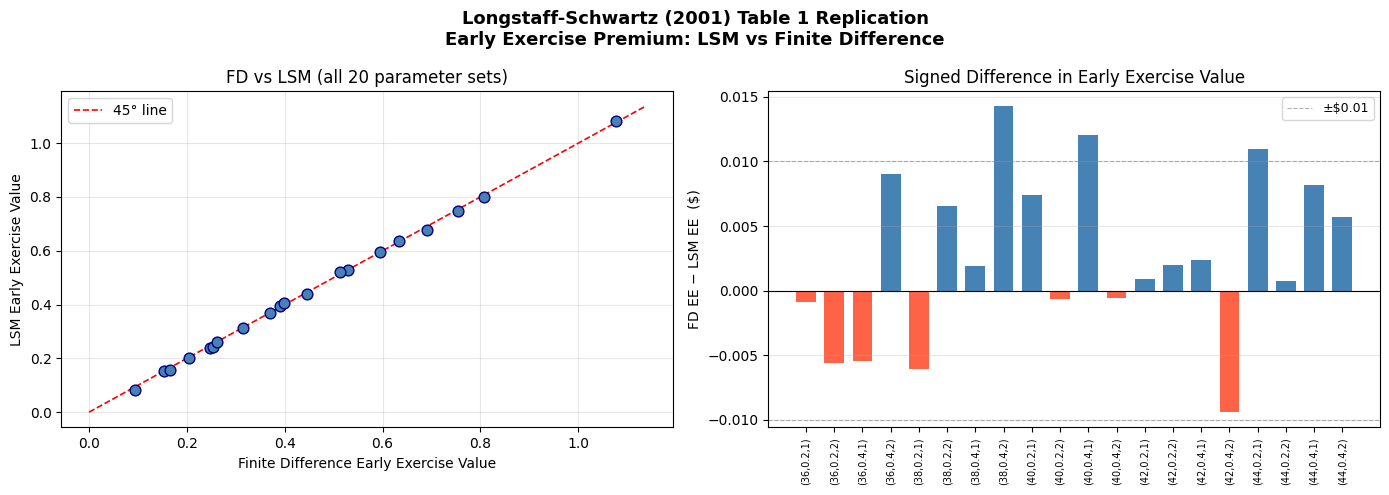

In [11]:
# =============================================================================
# 7.  Visual comparison: LSM vs FD early-exercise premium
# =============================================================================
 
try:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mtick
 
    fd_ee_vals  = [r['FD_Early_Exercise_Value']  for r in results]
    lsm_ee_vals = [r['LSM_Early_Exercise_Value'] for r in results]
    labels      = [f"S={r['S']}\nσ={r['sigma']}\nT={r['T']}" for r in results]
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Longstaff-Schwartz (2001) Table 1 Replication\n"
                 "Early Exercise Premium: LSM vs Finite Difference",
                 fontsize=13, fontweight='bold')
 
    # ── Scatter: FD vs LSM early-exercise value ───────────────────────────────
    ax = axes[0]
    ax.scatter(fd_ee_vals, lsm_ee_vals, color='steelblue', edgecolors='navy',
               s=60, zorder=3)
    lims = [0, max(max(fd_ee_vals), max(lsm_ee_vals)) * 1.05]
    ax.plot(lims, lims, 'r--', lw=1.2, label='45° line')
    ax.set_xlabel("Finite Difference Early Exercise Value")
    ax.set_ylabel("LSM Early Exercise Value")
    ax.set_title("FD vs LSM (all 20 parameter sets)")
    ax.legend()
    ax.grid(True, alpha=0.3)
 
    # ── Bar chart: signed differences ────────────────────────────────────────
    ax2 = axes[1]
    colors = ['tomato' if d < 0 else 'steelblue' for d in diffs]
    x = np.arange(len(diffs))
    ax2.bar(x, diffs, color=colors, edgecolor='none', width=0.7)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.axhline( 0.01, color='grey', lw=0.8, ls='--', alpha=0.6)
    ax2.axhline(-0.01, color='grey', lw=0.8, ls='--', alpha=0.6, label='±$0.01')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f"({r['S']},{r['sigma']},{r['T']})" for r in results],
                        rotation=90, fontsize=7)
    ax2.set_ylabel("FD EE − LSM EE  ($)")
    ax2.set_title("Signed Difference in Early Exercise Value")
    ax2.legend(fontsize=9)
    ax2.grid(True, axis='y', alpha=0.3)
 
    plt.tight_layout()
    plt.show()

except ImportError:
    print("\n(matplotlib not available — skipping plots)")